In [26]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch

In [25]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   - -------------------------------------- 3.9/110.9 MB 20.5 MB/s eta 0:00:06
   -- ------------------------------------- 7.6/110.9 MB 18.9 MB/s eta 0:00:06
   ---- ----------------------------------- 11.5/110.9 MB 19.2 MB/s eta 0:00:06
   ----- ---------------------------------- 16.0/110.9 MB 19.5 MB/s eta 0:00:05
   ------- -------------------------------- 20.4/110.9 MB 19.8 MB/s eta 0:00:05
   -------- ------------------------------- 24.4/110.9 MB 19.6 MB/s eta 0:00:05
   ---------- ----------------------------- 28.8/110.9 MB 19.8 MB/s eta 0:00:05
   ----------- ---------------------------- 33.0/110.9 MB 19.7 MB/s eta 0:00:04
   ------------- -------------------------- 37.5/110.9 MB 19.8 MB/s eta 0:00:04
   --------------- ------------------------ 41.7/110.9 MB 19.9 MB


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
def surface_code_circuit(p, d): # physical error rate, distance
  return stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=d,
    distance=d,
    after_clifford_depolarization=p,
    after_reset_flip_probability=p,
    before_measure_flip_probability=p,
    before_round_data_depolarization=p)

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
  # Sample the circuit.
  sampler = circuit.compile_detector_sampler()
  detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

  # Configure a decoder using the circuit.
  detector_error_model = circuit.detector_error_model(decompose_errors=True)
  matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

  # Run the decoder.
  predictions = matcher.decode_batch(detection_events)

  # basically compare predictions with observable_flips (what we should have measured)

  # Count the mistakes.
  num_errors = 0
  for shot in range(num_shots):
    actual_for_shot = observable_flips[shot]
    predicted_for_shot = predictions[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
  return num_errors

def ler_mwpm(p, d): # logical error rate, minimum weight perfect matching
  num_shots = 100000
  circuit = surface_code_circuit(p, d)
  num_errors = count_logical_errors(circuit, num_shots) 

  return num_errors / num_shots

def plot_mwpm(): 
  num_shots = 100000
  for d in [3, 5, 7]:
    xs = []
    ys = []
    yerrs = []
    for noise in np.linspace(0.001, 0.008, 8):
      ler = ler_mwpm(noise, d)
      xs.append(noise)
      ys.append(ler)
      yerrs.append(np.sqrt(ler * (1 - ler) / num_shots))
    plt.errorbar(xs, ys, yerr=yerrs, fmt='o-', label="d=" + str(d), capsize=3)
  plt.loglog()
  plt.xlabel("physical error rate")
  plt.ylabel("logical error rate per shot")
  plt.legend()
  plt.show()


after_clifford: after every operation e.g. H gate, you will apply X, Y, Z with probability p/3 each <br/>
after_reset_flip: after you do a reset (you think you're resetted to 0 but reset to 1 with probability p) <br/>
before_measure_flip: you should measuring a 0 but with p you're measuring a 1 <br/>
before_round_data_depolarization: we apply the same general error - errors no operation (interaction with the environment - decohere) - idling error

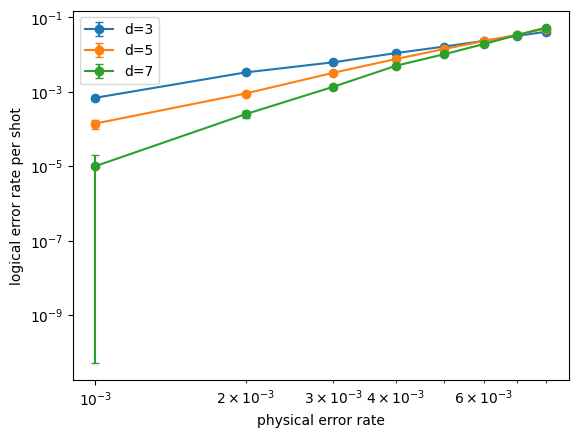

In [15]:
plot_mwpm()

In [35]:
train_size = 10**7
p = 0.005
d = 3

circuit = surface_code_circuit(p, d)
sampler = circuit.compile_detector_sampler()
detections, flips = sampler.sample(shots=train_size, separate_observables=True)
# detections is input into decoder 

num_input = detections.shape[1]

detections = detections.astype(int) * 2 -1 # converts to +1 and -1 
detections, flips = torch.Tensor(detections), torch.Tensor(flips.astype(int).flatten())

In [36]:
from torch import nn

In [37]:
decoder = nn.Sequential(
  nn.Linear(num_input, 256),
  nn.SiLU(),
  nn.Linear(256, 512),
  nn.SiLU(),
  nn.Linear(512, 1024),
  nn.SiLU(),
  nn.Linear(1024, 1),
  nn.Sigmoid()
)
loss_fn = nn.BCELoss() # inverse of accuracy
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3) # tells you how to train 
# important here is lre, it cannot be too high, you are going to start missing out features, cannot be too slow, you are going to take forever

In [38]:
from tqdm.auto import *

def train_loop(measurements, flips, bs=200):
  decoder.train()
  running_avg = 0
  with trange(train_size//bs) as pbar:
    for batch in pbar:
      X = measurements[batch*bs:(batch+1)*bs]
      y = flips[batch*bs:(batch+1)*bs][:,None]
      #pred = decoder(X.reshape((-1, 5*12)))
      pred = decoder(X)
      loss = loss_fn(pred, y)
      acc = torch.mean(((pred>0.5) == y).float())
      running_avg = acc * 0.01 + running_avg*0.99 if running_avg != 0 else acc
      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      if batch % 100 == 0:
        pbar.set_description(f'{running_avg:>4f} {loss:.4f}')

In [39]:
train_loop(detections, flips, bs=256)
train_loop(detections, flips, bs=8000) # model remmebers the first trian_loop, trains on top

0.983536 0.0391:  52%|█████▏    | 20386/39062 [01:08<01:03, 296.16it/s]


KeyboardInterrupt: 

In [44]:
1 - ler_mwpm(p, d) # accuracy of ler_mwpm, already beat,but iwht larger distances you would need more data to beat

0.98289

In [22]:
detections.shape

(1000000, 24)

In [29]:
detections

tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1.,  1.,  1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]])